

- 데이터: IMDb (Hugging Face datasets)

- 모델: Embedding → BiLSTM → Linear


In [1]:
# Colab 사전 설치 & 버전 확인 (2025 기준)
# - PyTorch 2.2+ / Transformers 4.45+ / Datasets 3.0+ 권장
# - 이미 설치되어 있어도 최신으로 맞춤

!pip -q install -U "torch>=2.2, <3.0" "torchvision>=0.17, <1.0" "torchaudio>=2.2, <3.0"
!pip -q install -U "datasets>=3.0.1" "transformers>=4.45.2" "accelerate>=1.0.1" "evaluate>=0.4.2" "scikit-learn>=1.5.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 133.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 154.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 57.2 MB/s eta 0:00:00


In [2]:
import torch, transformers, datasets, sklearn, evaluate, sys, platform
print("Python            :", sys.version.split()[0])
print("Platform          :", platform.platform())
print("PyTorch           :", torch.__version__)
print("Transformers      :", transformers.__version__)
print("Datasets          :", datasets.__version__)
print("scikit-learn      :", sklearn.__version__)
print("evaluate          :", evaluate.__version__)
print("CUDA available    :", torch.cuda.is_available())
print("GPU device        :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


Python            : 3.12.12
Platform          : Linux-6.6.113+-x86_64-with-glibc2.35
PyTorch           : 2.10.0+cu128
Transformers      : 5.3.0
Datasets          : 4.7.0
scikit-learn      : 1.8.0
evaluate          : 0.4.6
CUDA available    : True
GPU device        : NVIDIA L4


In [3]:
# 라이브러리 임포트 & 시드 고정
import re, math, random, numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader
from datasets import load_dataset

# 재현성을 위해 시드 고정
SEED = 2025
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [4]:
# 데이터 로드: IMDb (Hugging Face datasets)
# load_dataset은 자동으로 캐시 관리해줍니다.
raw = load_dataset("imdb")  # {'train':..., 'test':...}
print(raw)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [5]:
# [간단 토크나이저 정의(정규식): 영문 단어 분할
# 영어 소문자/숫자 단어만 추출, 나머지는 공백 처리
token_pattern = re.compile(r"[a-z0-9']+")
def simple_tokenize(text: str):
    # (한국어 주석) 소문자 변환 후 정규식 매칭
    return token_pattern.findall(text.lower())

In [6]:
# 어휘사전(Vocab) 구축
# 상위 N개 토큰만 사용하여 희소 단어는 <unk> 처리
from collections import Counter
MAX_VOCAB = 30000
PAD, UNK = "<pad>", "<unk>"

counter = Counter()
for ex in raw["train"]:
    counter.update(simple_tokenize(ex["text"]))

In [7]:
# 특수 토큰 포함하여 vocab 생성
most_common = counter.most_common(MAX_VOCAB - 2)
itos = [PAD, UNK] + [t for t, _ in most_common]  # index-to-string
stoi = {t:i for i, t in enumerate(itos)}         # string-to-index
PAD_IDX, UNK_IDX = stoi[PAD], stoi[UNK]
print("어휘 크기:", len(itos))

어휘 크기: 30000


In [8]:
counter.most_common(MAX_VOCAB - 2)[:5]

[('the', 336195),
 ('and', 164136),
 ('a', 163093),
 ('of', 145850),
 ('to', 135713)]

In [9]:
itos[:10]

['<pad>', '<unk>', 'the', 'and', 'a', 'of', 'to', 'is', 'br', 'in']

In [10]:
stoi["the"]

2

In [11]:
# 텍스트 -> 인덱스 변환 & 패딩/트렁케이션
MAX_LEN = 256  # (한국어 주석) 시퀀스 최대 길이

def encode(text: str):
    tokens = simple_tokenize(text)
    ids = [stoi.get(tok, UNK_IDX) for tok in tokens][:MAX_LEN]
    if len(ids) < MAX_LEN:
        ids += [PAD_IDX] * (MAX_LEN - len(ids))
    return ids

def encode_label(y: int):
    # (한국어 주석) IMDb: 0=neg, 1=pos
    return int(y)

In [12]:
# PyTorch Dataset 래핑
class IMDBTensor(torch.utils.data.Dataset):
    def __init__(self, hf_split):
        self.data = hf_split
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        text = self.data[idx]["text"]
        label = self.data[idx]["label"]
        x = torch.tensor(encode(text), dtype=torch.long)
        y = torch.tensor(encode_label(label), dtype=torch.long)
        return x, y

train_ds = IMDBTensor(raw["train"])
test_ds  = IMDBTensor(raw["test"])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

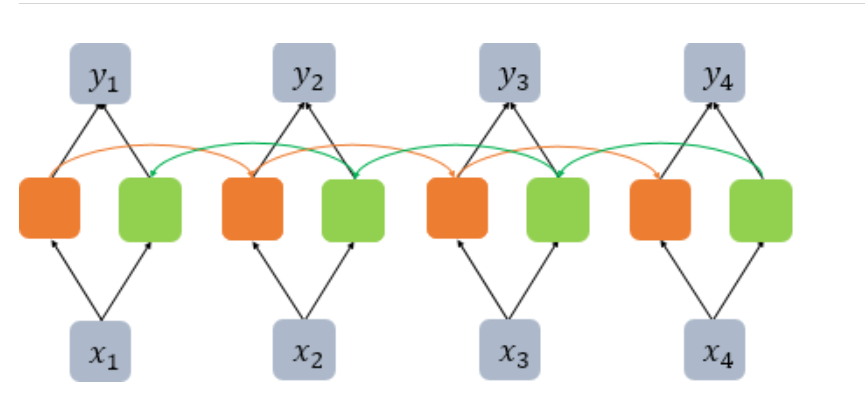

In [13]:
# 모델 정의: 임베딩 + 양방향 LSTM + FC
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, emb=128, hidden=128, num_layers=1, num_classes=2, pad_idx=0, dropout=0.2):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb, padding_idx=pad_idx)
        self.lstm = nn.LSTM(emb, hidden, num_layers=num_layers, batch_first=True, bidirectional=True, dropout=0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden*2, num_classes)  # 양방향 → 2배, num_classes = 2(1=긍정, 0=부정)
        # (한국어 주석) Kaiming 초기화
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: (B, T)
        e = self.emb(x)                 # (Batch, Token, Embedding)
        out, (h, c) = self.lstm(e)      # h: (num_layers*2, B, H)
        # (한국어 주석) 마지막 레이어의 forward/backward hidden state 결합
        last_f = h[-2]                  # (B, H) forward 방향
        last_b = h[-1]                  # (B, H) backward 방향
        h_cat = torch.cat([last_f, last_b], dim=1)  # (B, 2H)
        h_cat = self.dropout(h_cat)
        logits = self.fc(h_cat)         # (B, C)
        return logits

model = BiLSTM(len(itos), emb=128, hidden=128, num_layers=1, pad_idx=PAD_IDX).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

In [14]:
# 학습/평가 루프
def train_one_epoch(epoch):
    model.train()
    total_loss = total_correct = total = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    print(f"[Train] Epoch {epoch} | loss={total_loss/total:.4f} | acc={total_correct/total:.4f}")

@torch.no_grad()
def evaluate():
    model.eval()
    total_loss = total_correct = total = 0
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        loss = criterion(logits, y)
        total_loss += loss.item() * y.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    print(f"[Test ] loss={total_loss/total:.4f} | acc={total_correct/total:.4f}")

EPOCHS = 3  # 2~3 에폭 권장
for ep in range(1, EPOCHS+1):
    train_one_epoch(ep)
    evaluate()


[Train] Epoch 1 | loss=0.6452 | acc=0.6194
[Test ] loss=0.5863 | acc=0.6884
[Train] Epoch 2 | loss=0.5124 | acc=0.7513
[Test ] loss=0.5829 | acc=0.6909
[Train] Epoch 3 | loss=0.3830 | acc=0.8339
[Test ] loss=0.5265 | acc=0.7451


In [15]:
# EOS